# Exploratory Data Analysis — Online Shoppers Purchasing Intention

**Objective.** Determine whether session-level browsing behaviour can predict purchase
(`Revenue` = True/False), and identify which features carry that signal.

The analysis proceeds bottom-up so that conclusions follow from evidence rather than precede it:
(1) data integrity, (2) univariate distributions of every feature, (3) each feature's relationship
to the target, (4) correlation-based ranking, (5) the seasonal axis used for drift, (6) conclusions
mapped to pipeline decisions. No predictor is privileged in advance.

> **Execution.** Run via `kedro jupyter lab` to use the Kedro `catalog`; otherwise the load cell
> reads the CSV directly.

**Dataset.** UCI *Online Shoppers Purchasing Intention* (id=468): 12,330 sessions, 18 columns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Prefer the Kedro catalog (single source of truth). Fall back to the raw CSV
# if this notebook is run outside a `kedro jupyter` session.
try:
    df = catalog.load("online_shoppers_raw")           # noqa: F821 (injected by kedro jupyter)
    print("Loaded via Kedro catalog.")
except NameError:
    df = pd.read_csv("../data/01_raw/online_shoppers.csv")
    print("Loaded via direct CSV read (no Kedro session).")

print("Shape:", df.shape)
df.head()

Loaded via direct CSV read (no Kedro session).
Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 1. Data integrity

Type correctness, missing values, and duplication are checked first, as each has direct
consequences for the downstream data-quality gate and cleaning steps.

In [2]:
print("=== column types ===")
print(df.dtypes)

print("\n=== missing values ===")
missing = df.isna().sum()
print(missing[missing > 0] if missing.sum() else "None — every cell is populated.")

print("\n=== duplicate rows ===")
print(f"{df.duplicated().sum()} fully-identical rows")

=== column types ===
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

=== missing values ===
None — every cell is populated.

=== duplicate rows ===
125 fully-identical rows


**Findings.** No missing values. **125 fully-identical rows** are present, and **no identifier column**.

The duplicates are retained rather than dropped: identical low-activity sessions (e.g. single page,
immediate exit, no purchase) are behaviourally plausible and likely represent distinct visitors, so
removing them would discard valid observations and shift the class balance. The absence of a key is
handled in the pipeline by generating an `index` column in the `feature_store` step.

## 2. Univariate distributions

The marginal distribution of each variable is examined before any target relationship. Skew, bounded
ranges, and dominant categories determine later scaling, encoding, and data-quality range rules.
Numeric and categorical features are treated separately as they require different handling.

### 2a. Numeric features

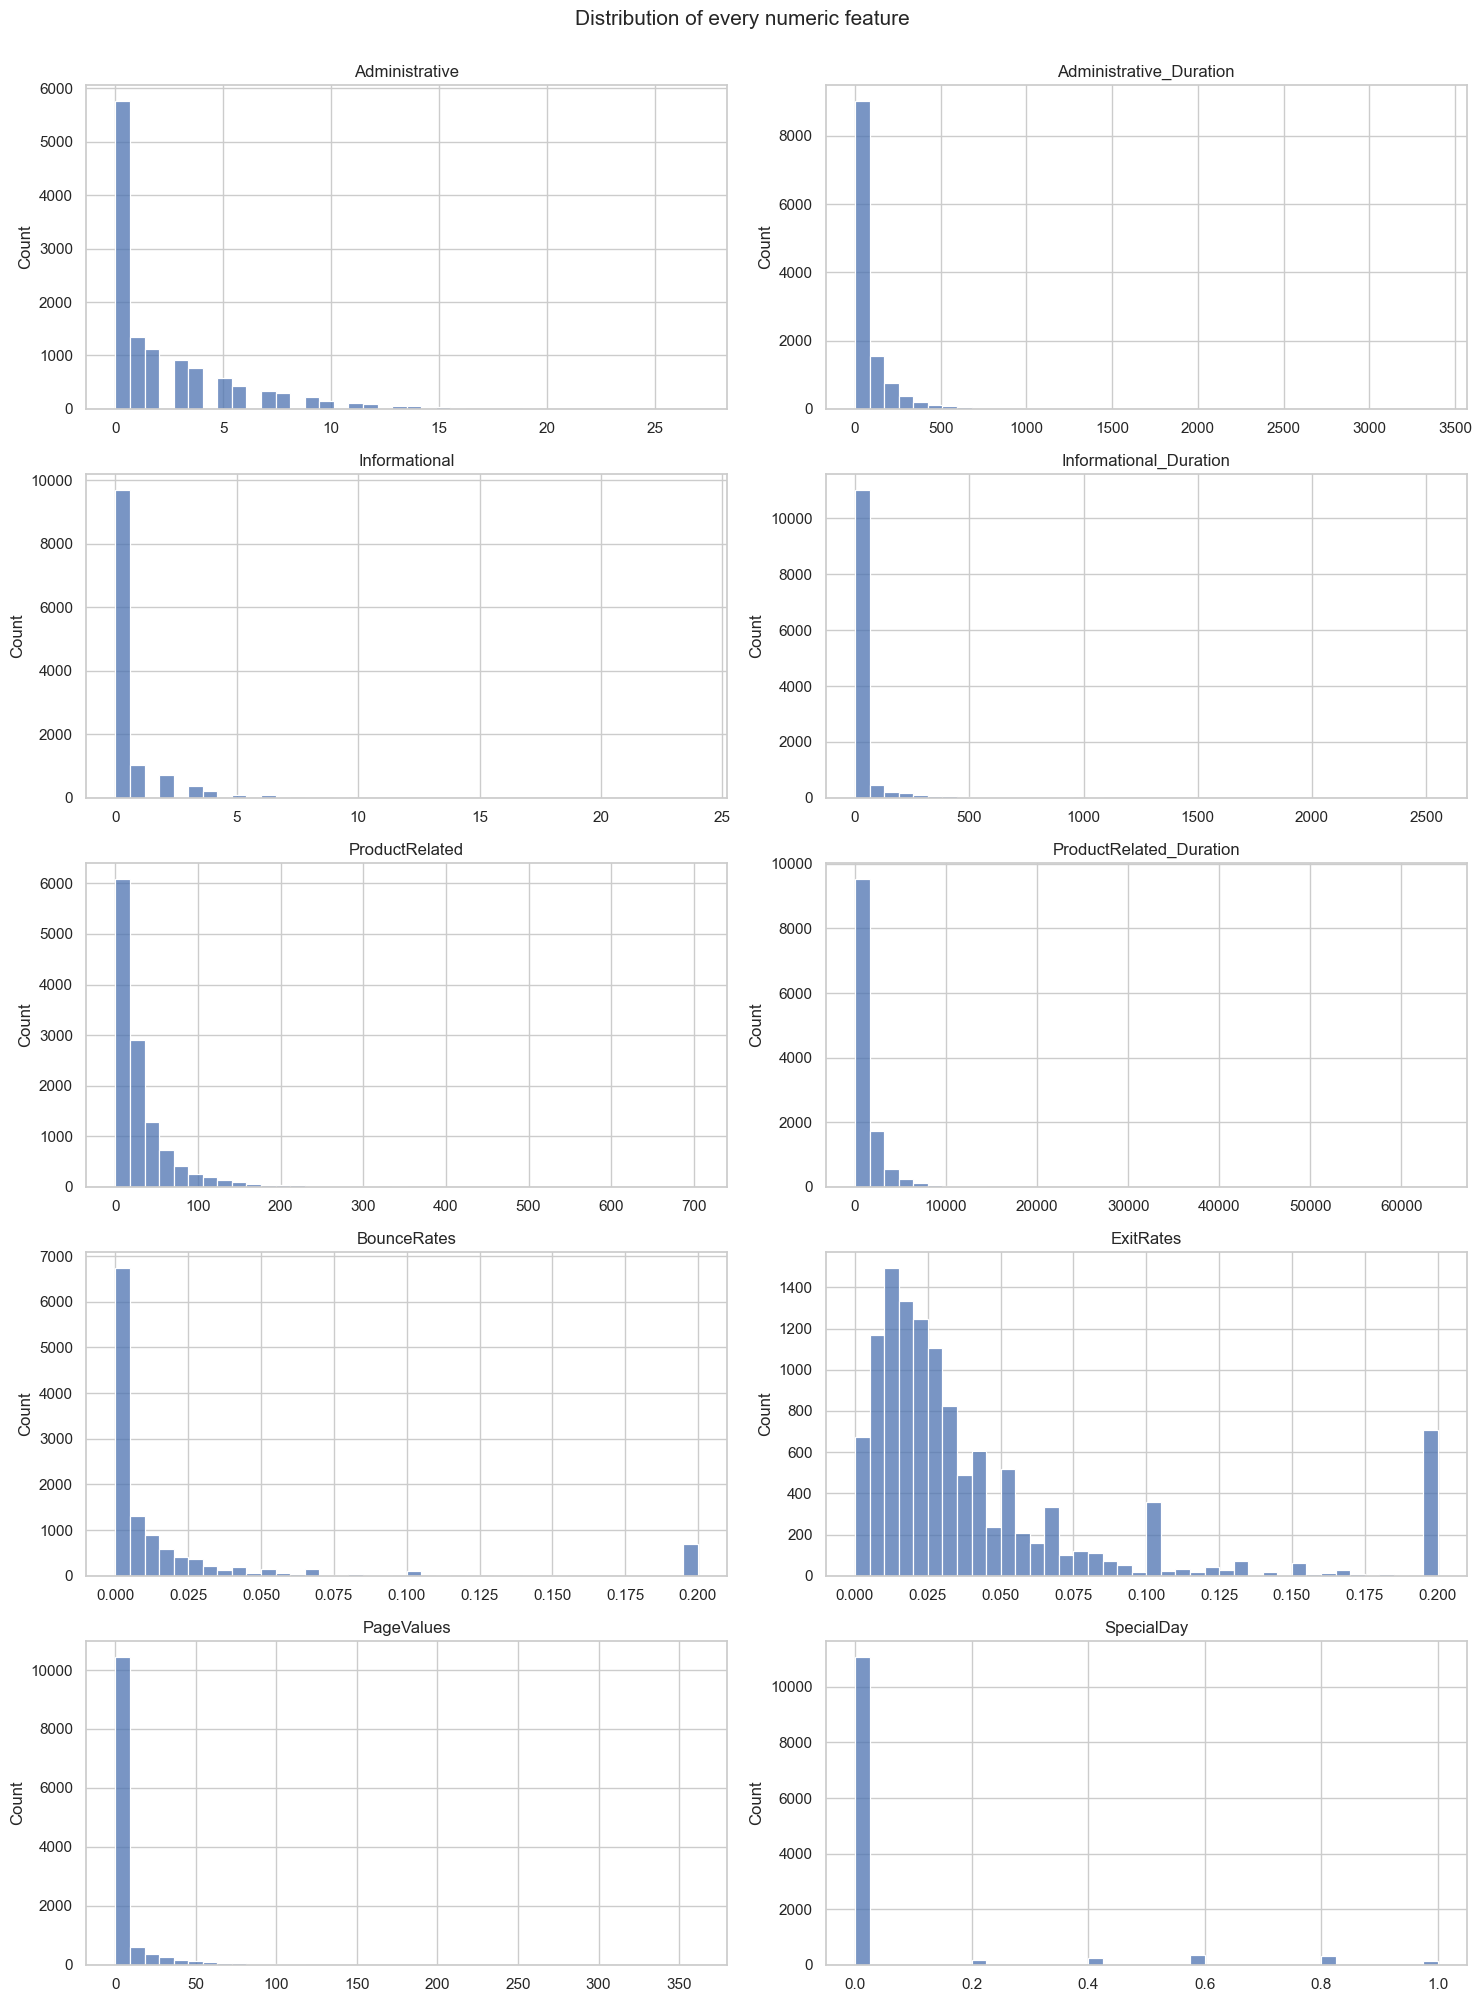

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.32,3.32,0.0,0.00,1.00,4.00,27.00
Administrative_Duration,12330.0,80.82,176.78,0.0,0.00,7.50,93.26,3398.75
Informational,12330.0,0.50,1.27,0.0,0.00,0.00,0.00,24.00
Informational_Duration,12330.0,34.47,140.75,0.0,0.00,0.00,0.00,2549.38
ProductRelated,12330.0,31.73,44.48,0.0,7.00,18.00,38.00,705.00
ProductRelated_Duration,12330.0,1194.75,1913.67,0.0,184.14,598.94,1464.16,63973.52
BounceRates,12330.0,0.02,0.05,0.0,0.00,0.00,0.02,0.20
ExitRates,12330.0,0.04,0.05,0.0,0.01,0.03,0.05,0.20
PageValues,12330.0,5.89,18.57,0.0,0.00,0.00,0.00,361.76
SpecialDay,12330.0,0.06,0.20,0.0,0.00,0.00,0.00,1.00


In [3]:
numeric_cols = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay",
]

fig, axes = plt.subplots(5, 2, figsize=(15, 20))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("")
fig.suptitle("Distribution of every numeric feature", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

df[numeric_cols].describe().T.round(2)

**Observations.**

- Count and duration features are **strongly right-skewed**; most sessions are brief, with a long tail
  (`ProductRelated_Duration` reaches ~64,000 s). This motivates scaling for linear and distance-based models.
- `BounceRates` and `ExitRates` are confined to ~[0, 0.2]; as rates they are bounded in [0, 1] — a usable
  data-quality constraint.
- `PageValues` is zero for most sessions with a sparse positive tail.
- `SpecialDay` is near-zero for the majority and behaves as a sparse flag.

### 2b. Categorical features

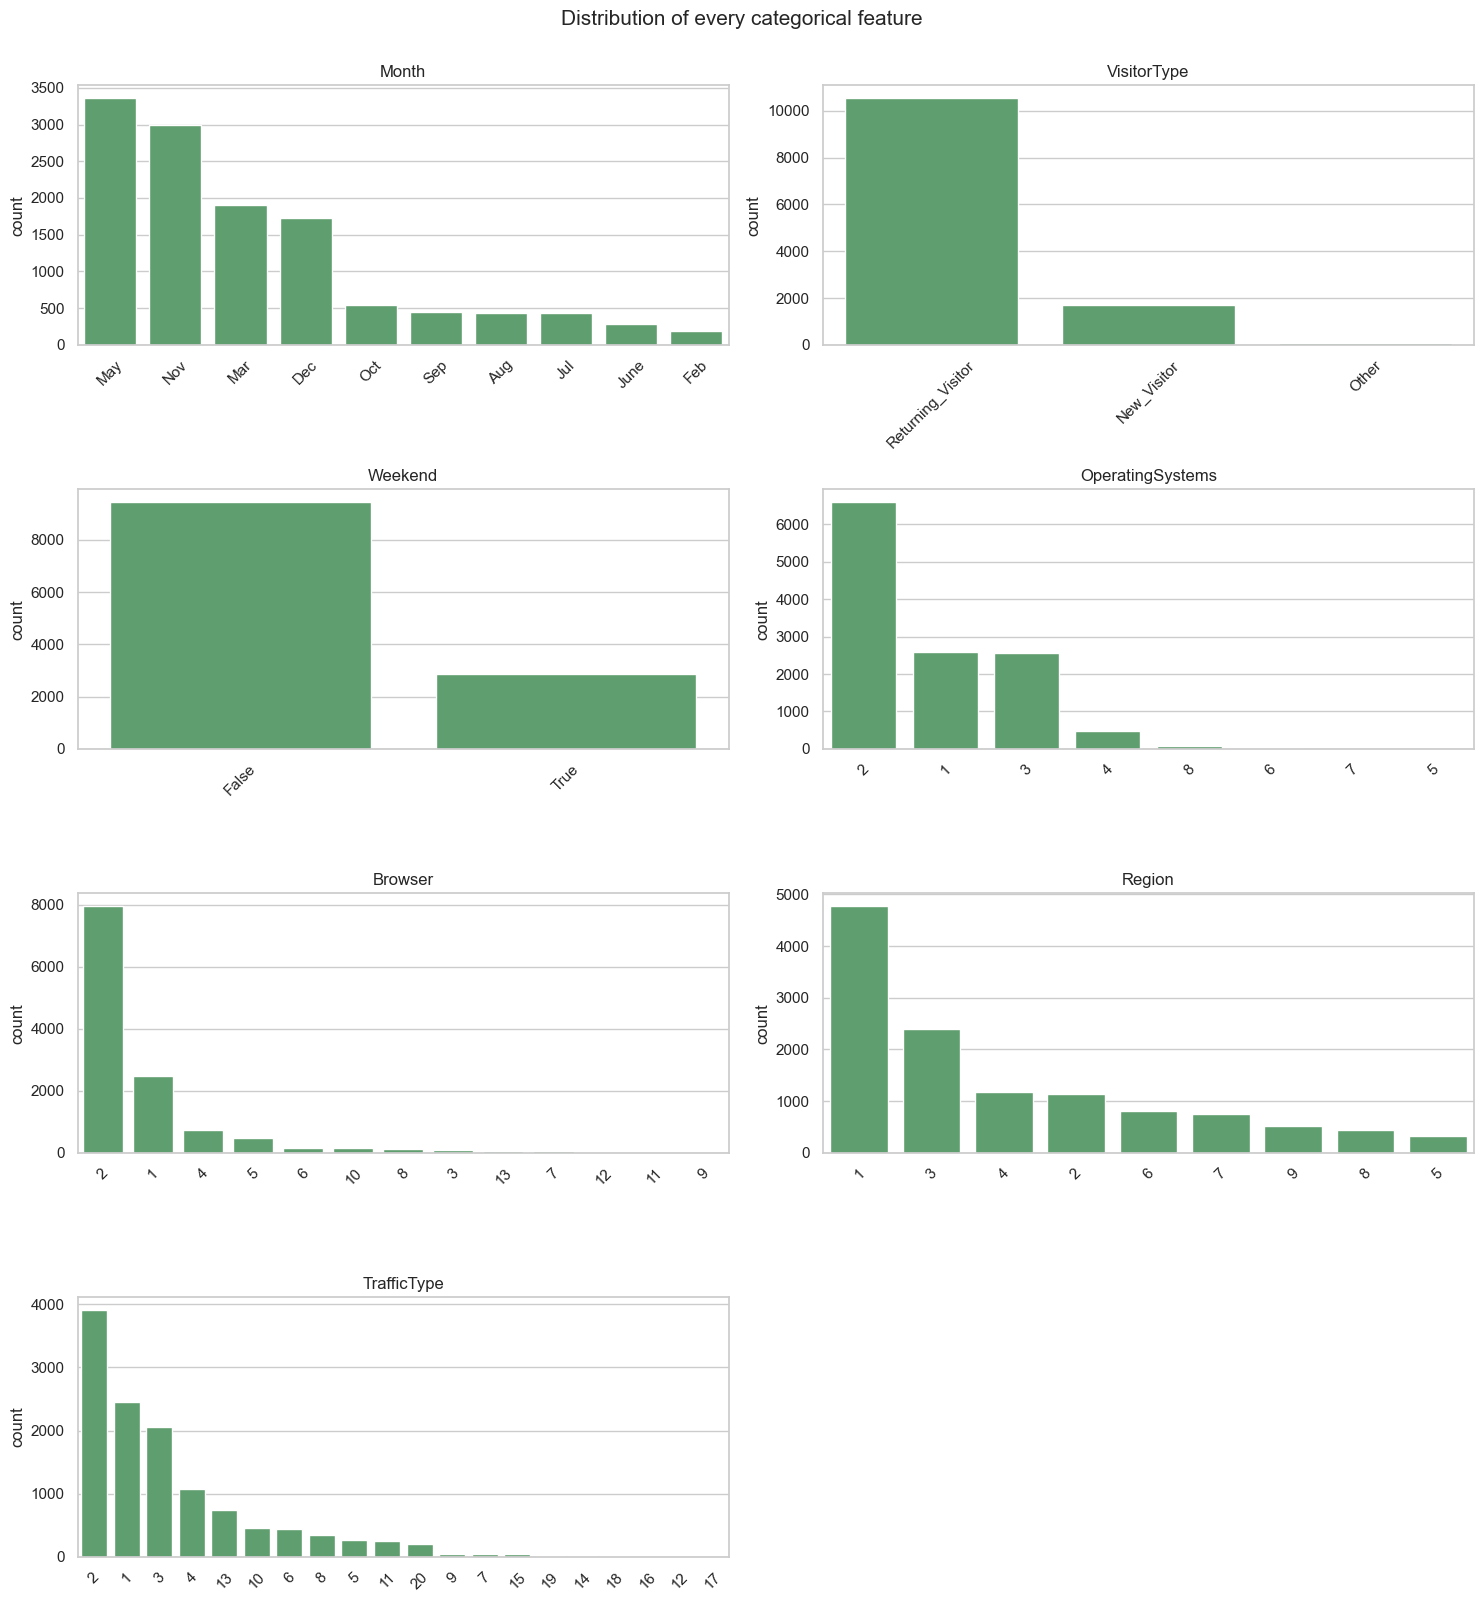

-- Month --
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

-- VisitorType --
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

-- Weekend --
Weekend
False    9462
True     2868
Name: count, dtype: int64



In [4]:
# True categoricals + the "integers that are really categories" (OS/Browser/Region/TrafficType:
# OS "2" is not twice OS "1" — treating them as magnitudes would be a modelling error).
cat_cols = ["Month", "VisitorType", "Weekend",
            "OperatingSystems", "Browser", "Region", "TrafficType"]

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, ax=ax, color="#55A868")
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
axes.ravel()[-1].axis("off")  # only 7 categoricals, blank the 8th panel
fig.suptitle("Distribution of every categorical feature", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

for c in ["Month", "VisitorType", "Weekend"]:
    print(f"-- {c} --\n{df[c].value_counts()}\n")

**Observations.**

- `VisitorType` is dominated by returning visitors (~88%).
- `Weekend` is predominantly False; weekday sessions dominate.
- `Month` is uneven (May and November overrepresented; January and April absent), indicating a temporal axis.
- `OperatingSystems` (8), `Browser` (13), `Region` (9), and `TrafficType` (20) are integer-coded but are
  **nominal categories**; their numeric codes carry no ordinal meaning and must be **encoded, not scaled**.

## 3. Bivariate relationships with the target

Each feature is compared across the two purchase outcomes. Numeric and categorical features are
assessed in turn, without preselection, to establish which separate buyers from non-buyers.

### 3a. Numeric features by outcome

In [5]:
# Mean of each numeric feature, split by purchase outcome, plus the ratio.
summary = df.groupby("Revenue")[numeric_cols].mean().T
summary.columns = ["no_buy", "buy"]
summary["ratio_buy_vs_nobuy"] = (summary["buy"] / summary["no_buy"].replace(0, np.nan)).round(1)
summary.round(2)

,no_buy,buy,ratio_buy_vs_nobuy
Administrative,2.12,3.39,1.6
Administrative_Duration,73.74,119.48,1.6
Informational,0.45,0.79,1.7
Informational_Duration,30.24,57.61,1.9
ProductRelated,28.71,48.21,1.7
ProductRelated_Duration,1069.99,1876.21,1.8
BounceRates,0.03,0.01,0.2
ExitRates,0.05,0.02,0.4
PageValues,1.98,27.26,13.8
SpecialDay,0.07,0.02,0.3


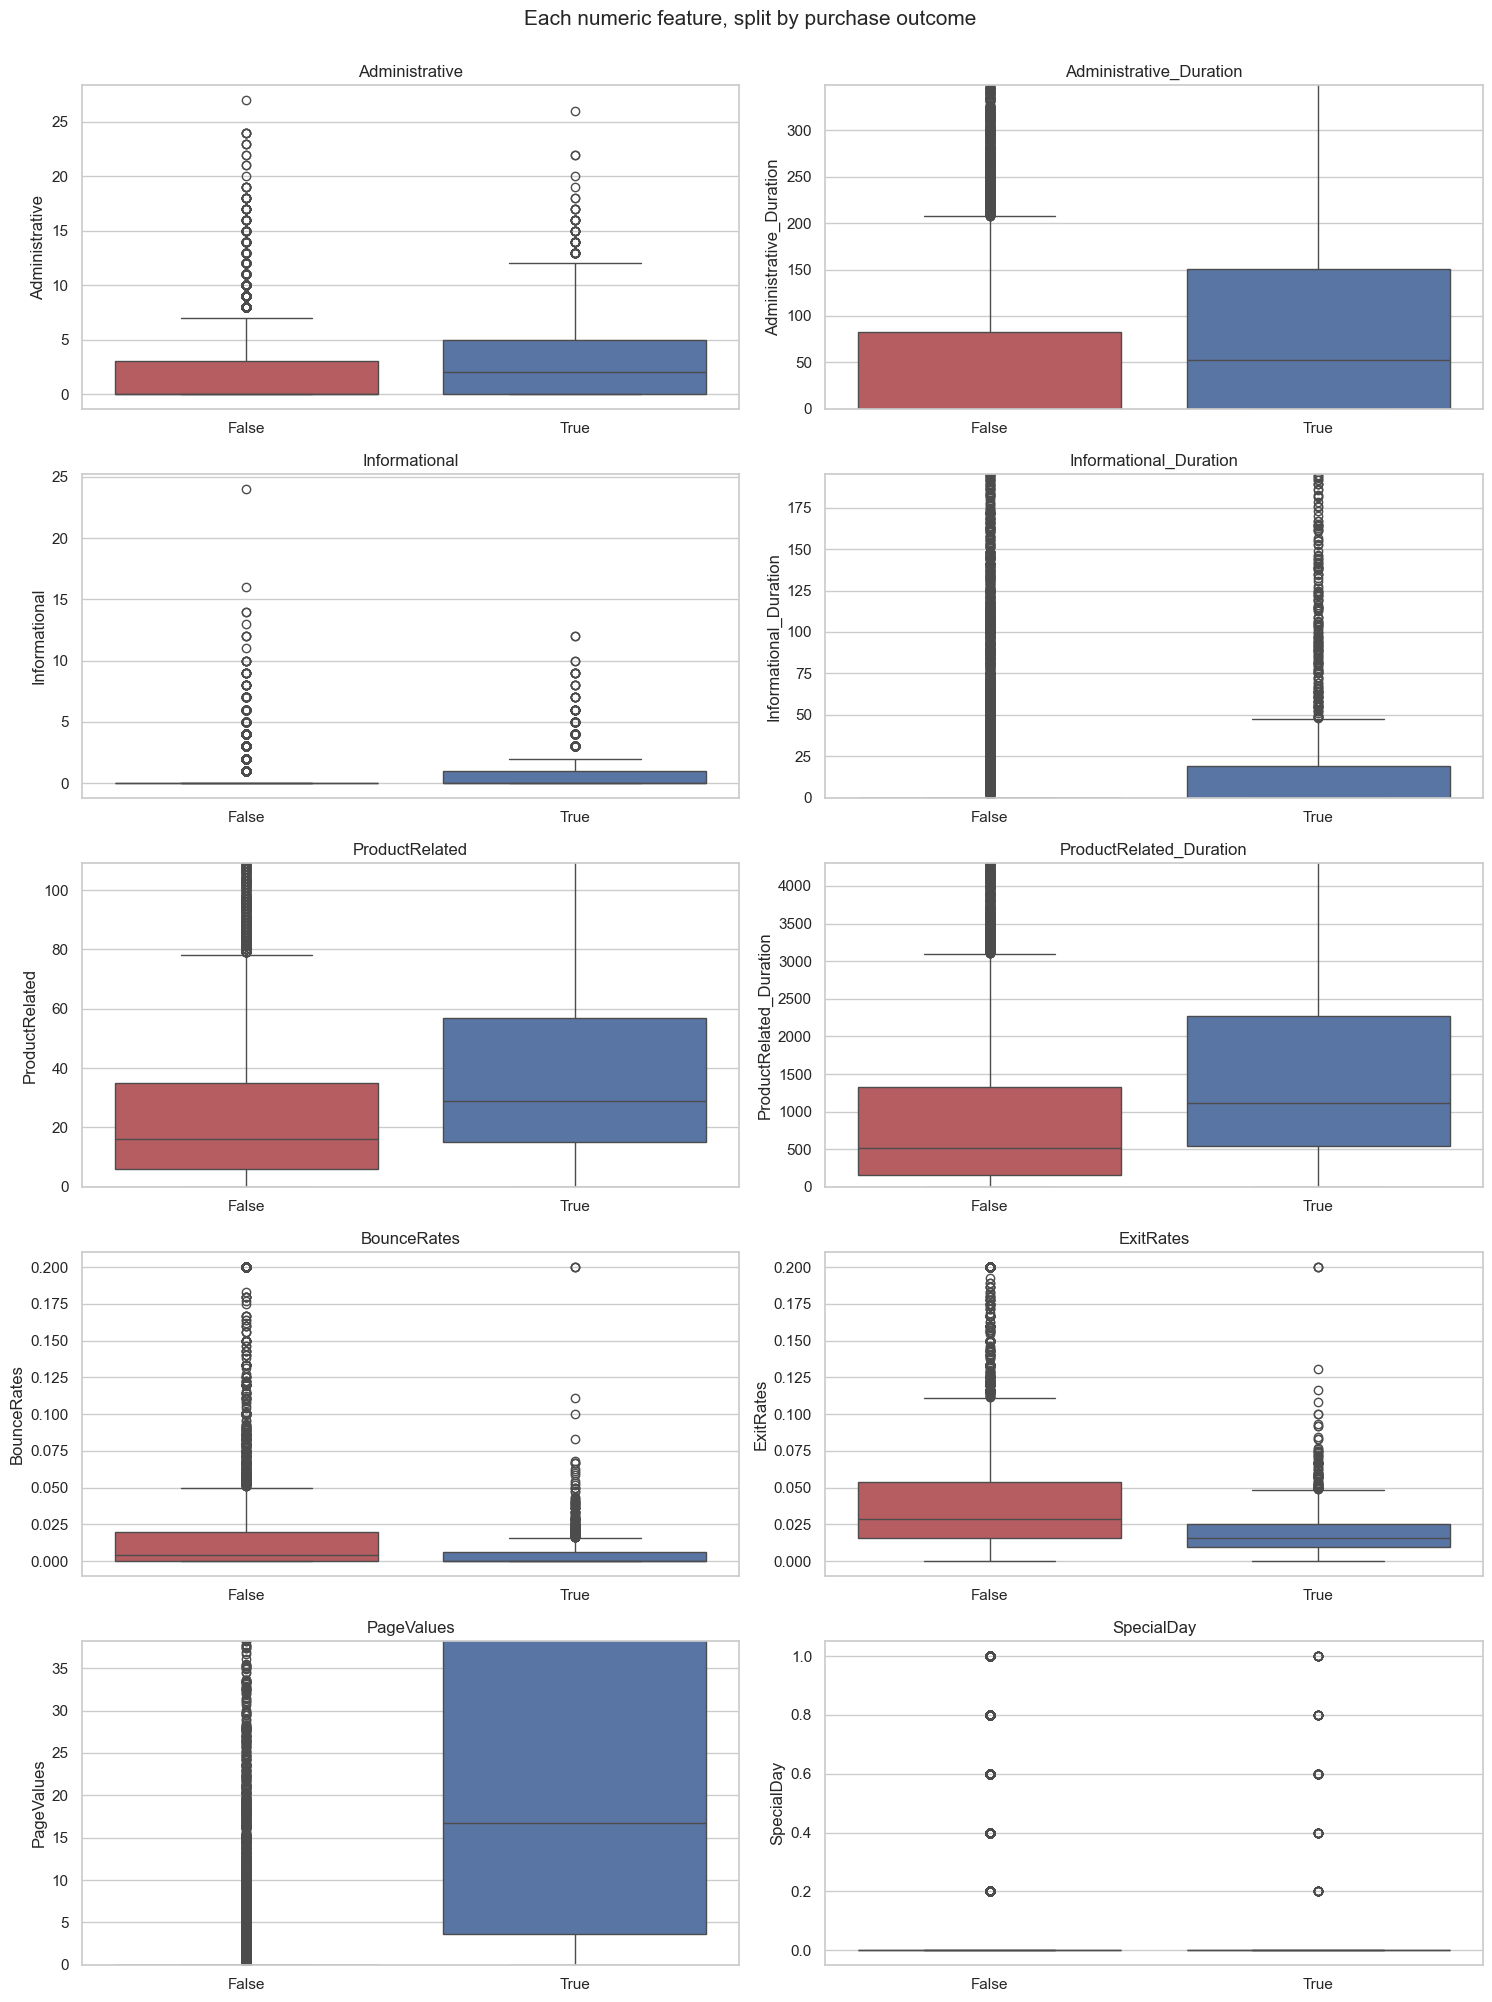

In [6]:
# Visualise the separation: boxplots of each numeric feature by outcome.
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(x="Revenue", y=col, data=df, hue="Revenue", legend=False,
                palette=["#C44E52", "#4C72B0"], ax=ax)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("")
    # clip the worst skew so the boxes are readable
    if col.endswith("Duration") or col in ("PageValues", "ProductRelated"):
        upper = df[col].quantile(0.95)
        ax.set_ylim(0, max(upper, 1))
fig.suptitle("Each numeric feature, split by purchase outcome", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

**Observations.** Multiple features separate the classes: buyers view more product pages, spend longer,
and exhibit lower exit and bounce rates. The separation is largest for `PageValues`, whose
buyer/non-buyer mean ratio in the table exceeds that of all other features by a wide margin. This is
quantified formally in Section 4.

### 3b. Purchase rate by category

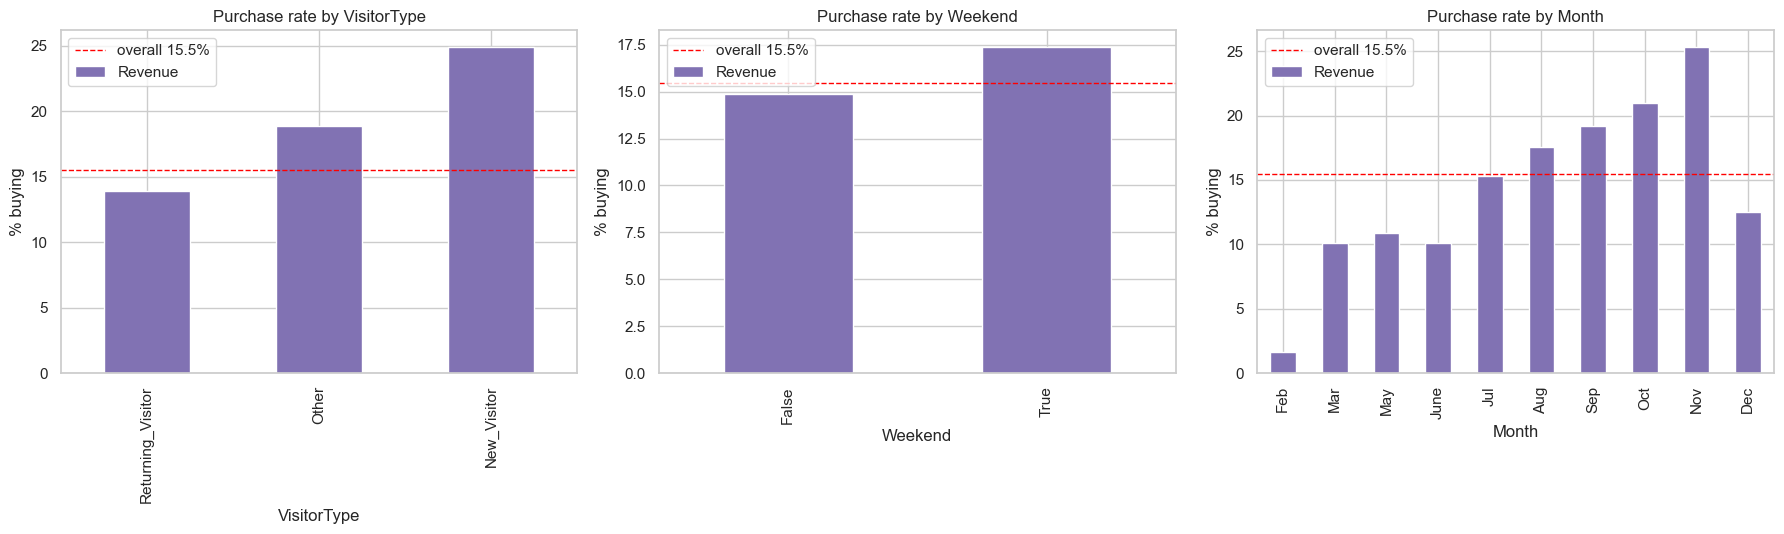

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
overall = df["Revenue"].mean() * 100
for ax, col in zip(axes, ["VisitorType", "Weekend", "Month"]):
    if col == "Month":
        order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    else:
        order = None
    rate = (df.groupby(col)["Revenue"].mean() * 100)
    rate = rate.reindex(order) if order else rate.sort_values()
    rate.plot(kind="bar", ax=ax, color="#8172B3")
    ax.axhline(overall, color="red", ls="--", lw=1, label=f"overall {overall:.1f}%")
    ax.set_title(f"Purchase rate by {col}")
    ax.set_ylabel("% buying")
    ax.legend()
plt.tight_layout()
plt.show()

**Observations.**

- `Month` shows the largest categorical effect: purchase rate ranges from ~1.6% (February) to ~25%
  (November), consistent with holiday-season demand.
- New visitors convert somewhat higher than returning visitors.
- Weekend status has negligible effect.

The monthly effect underpins the data-drift component (Section 5).

## 4. Correlation-based ranking

The qualitative separation above is now quantified: each numeric feature is ranked by its correlation
with the target, and the full correlation matrix is inspected for redundancy between features.

Correlation with Revenue (ranked)
PageValues                 0.493
ProductRelated             0.159
ProductRelated_Duration    0.152
Administrative             0.139
Informational              0.095
Administrative_Duration    0.094
Informational_Duration     0.070
SpecialDay                -0.082
BounceRates               -0.151
ExitRates                 -0.207


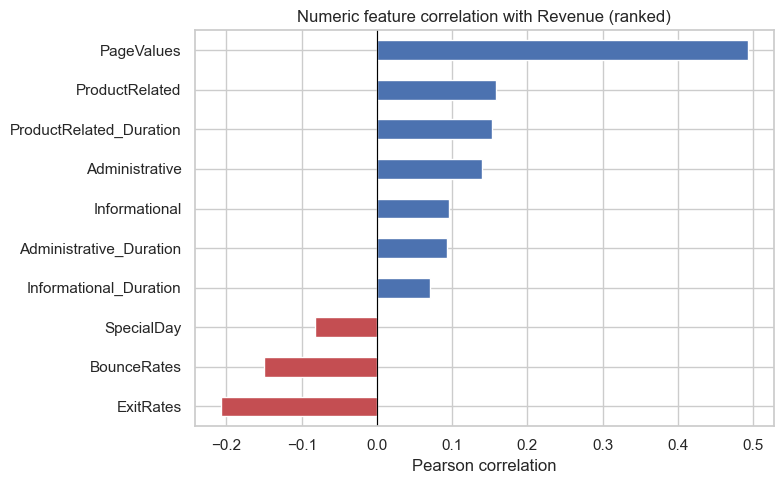

In [8]:
# Encode the boolean target so it can enter the correlation computation.
corr_df = df[numeric_cols + ["Revenue"]].copy()
corr_df["Revenue"] = corr_df["Revenue"].astype(int)

# (i) Ranked correlation of every numeric feature with the target.
correlation_with_target = (
    corr_df.corr()["Revenue"].drop("Revenue").sort_values(ascending=False)
)
print("Correlation with Revenue (ranked)")
print("=" * 45)
print(correlation_with_target.round(3).to_string())

# (ii) Same ranking as a horizontal bar chart (positive vs negative drivers).
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in correlation_with_target]
correlation_with_target.plot(kind="barh", color=colors, ax=ax)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Numeric feature correlation with Revenue (ranked)")
ax.set_xlabel("Pearson correlation")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

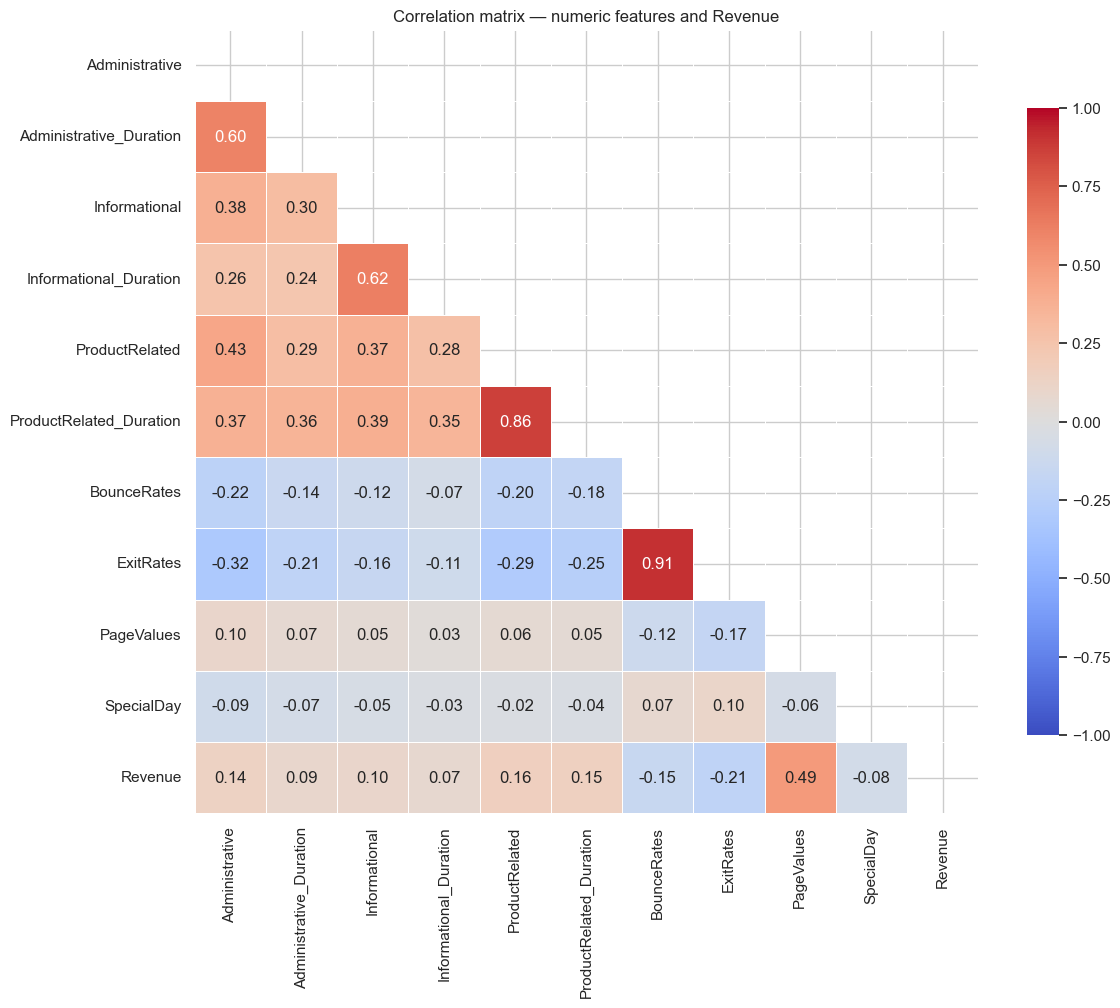

In [9]:
# (iii) Full correlation matrix (features + target) to expose redundancy
#       between predictors, e.g. BounceRates vs ExitRates.
plt.figure(figsize=(12, 10))
correlation_matrix = corr_df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # upper triangle hidden
sns.heatmap(
    correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, linewidths=0.5, square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation matrix — numeric features and Revenue")
plt.tight_layout()
plt.show()

**Results.** The ranking confirms the bivariate analysis:

- `PageValues` has the strongest correlation with purchase by a clear margin; buyers average ~27 versus
  ~2 for non-buyers (~14× difference). It is identified as the leading predictor by the data, not by prior
  assumption.
- `ExitRates` and `BounceRates` are the strongest negative correlates and are mutually correlated,
  indicating partial redundancy relevant to feature selection.
- Product-browsing volume and duration features form a weaker positive cluster.

The model's SHAP analysis (Sprint 2) provides an independent check on this ranking.

## 5. Seasonal axis for drift evaluation

The monthly purchase-rate variation is examined directly, as it provides the basis for the data-drift
component (requirement #5).

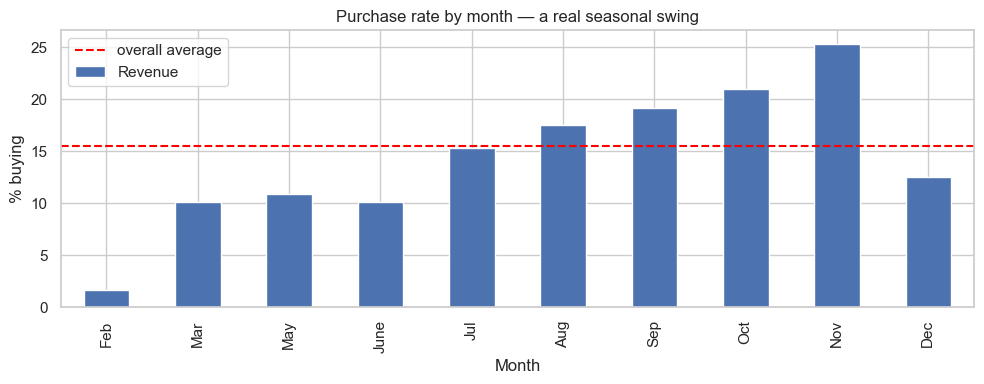

Month
Feb      1.6
Mar     10.1
May     10.9
June    10.1
Jul     15.3
Aug     17.6
Sep     19.2
Oct     20.9
Nov     25.4
Dec     12.5
Name: Revenue, dtype: float64

In [10]:
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
by_month = (df.groupby("Month")["Revenue"].mean() * 100).reindex(month_order)

fig, ax = plt.subplots(figsize=(10, 4))
by_month.plot(kind="bar", ax=ax, color="#4C72B0")
ax.axhline(df["Revenue"].mean() * 100, color="red", ls="--", label="overall average")
ax.set_title("Purchase rate by month — a real seasonal swing")
ax.set_ylabel("% buying")
ax.legend()
plt.tight_layout()
plt.show()

by_month.round(1)

### Report figure: combined EDA overview

The two headline findings are combined into a single figure used in the report
(`data/08_reporting/eda_overview.png`): the seasonal conversion swing (left) and the
`PageValues` separation between buyers and non-buyers (right). Regenerating this cell
reproduces the exact image embedded in the report, keeping the notebook the source of truth.

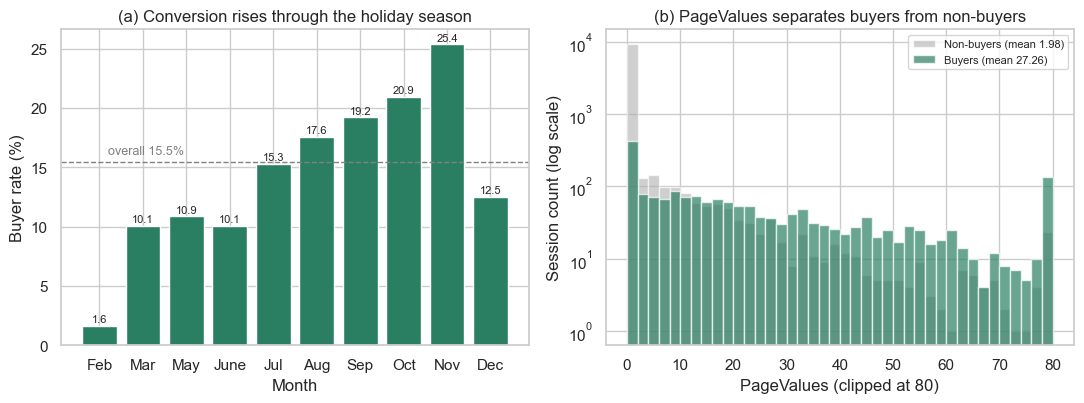

Saved report figure -> C:\Users\USER\Desktop\School Work\SECOND SEMESTER\MLOPs\Practical_Classes-20260522\MLOPs Project\data\08_reporting\eda_overview.png


In [11]:
import pathlib

# (a) buyer rate by month, calendar-ordered; (b) PageValues distribution by outcome.
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
rate = (df.groupby("Month")["Revenue"].mean() * 100).reindex(month_order)
overall = df["Revenue"].mean() * 100
green = "#2a7f62"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

bars = ax1.bar(rate.index, rate.values, color=green)
ax1.axhline(overall, color="grey", linestyle="--", linewidth=1)
ax1.text(0.2, overall + 0.6, f"overall {overall:.1f}%", color="grey", fontsize=9)
ax1.set_ylabel("Buyer rate (%)"); ax1.set_xlabel("Month")
ax1.set_title("(a) Conversion rises through the holiday season")
for b, v in zip(bars, rate.values):
    ax1.text(b.get_x() + b.get_width() / 2, v + 0.3, f"{v:.1f}", ha="center", fontsize=8)

buyers = df.loc[df["Revenue"], "PageValues"].clip(upper=80)
nonbuyers = df.loc[~df["Revenue"], "PageValues"].clip(upper=80)
ax2.hist(nonbuyers, bins=40, alpha=0.6, label="Non-buyers (mean 1.98)", color="#b0b0b0")
ax2.hist(buyers, bins=40, alpha=0.7, label="Buyers (mean 27.26)", color=green)
ax2.set_yscale("log")
ax2.set_ylabel("Session count (log scale)"); ax2.set_xlabel("PageValues (clipped at 80)")
ax2.set_title("(b) PageValues separates buyers from non-buyers")
ax2.legend(fontsize=8)

fig.tight_layout()
out = pathlib.Path("../data/08_reporting/eda_overview.png")
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print("Saved report figure ->", out.resolve())


**Rationale.** The seasonal effect supplies a genuine distribution shift rather than a synthetic one.
In Sprint 4 the data is split on time — lower-season months as the reference window and a holiday-season
batch (e.g. November) as the current window — allowing Evidently to detect a real, business-attributable
shift. This is preferable to artificially perturbing a feature.

## 6. Conclusions and pipeline implications

The findings above translate directly into pipeline design decisions:

| What the data showed | What the pipeline does about it | Sprint |
|---|---|---|
| No missing values; 125 identical rows are plausibly real sessions; no ID column | Keep duplicates (documented); GX type/range gate; create an `index` key in the feature store | S1 |
| Only **15.5%** of sessions buy → imbalance | Success metric = **recall on buyers / F1 / ROC-AUC** (not accuracy); `class_weight='balanced'` | S2 |
| `BounceRates`/`ExitRates` ∈ [0, ~0.2], durations ≥ 0, `SpecialDay` ∈ [0, 1], `Revenue` ∈ {T, F} | These bounds become **Great Expectations range checks** (≥6 asserts) | S1 |
| OS / Browser / Region / TrafficType are integer-coded **categories** | **Encode, don't scale** them; bool → int for `Revenue`/`Weekend` | S2 |
| Right-skewed durations/counts | Scaling decision; fit the scaler on **train only** (no leakage) | S2 |
| **`PageValues`** is the strongest predictor (~14× buyer gap, top correlation) | Expect it to lead the **SHAP** explanation — and check that it does | S2/S6 |
| `Month` drives purchase rate **~1.6% → ~25%** | Build **natural seasonal drift**: low-season reference vs. holiday current batch | S4 |

The type and range findings are operationalised in Sprint 1 as a Great Expectations suite (>= 6 asserts)
within the `data_quality` pipeline, which gates all downstream stages.